# Mouse Embryo Anaysis

### Download data

In [2]:
!uv init --python=3.8
!uv run python
!uv add stereopy --dev
!uv add ipykernel

Initialized project `stlens-tutorials`


you should put this code in main.py.

```
import stereo as st
import warnings
warnings.filterwarnings('ignore')

# read the GEF file
data_path = "./D05103C4D4.cellbin.gef"
data = st.io.read_gef(file_path=data_path, bin_type='cell_bins')
data.tl.raw_checkpoint()

# remember to set flavor as scanpy
adata = st.io.stereo_to_anndata(data, flavor='scanpy', output='scanpy_out.h5ad')
```

In [7]:
!uv run main.py

[2025-11-05 13:45:24][Stereo][3480830][MainThread][140003782453056][reader][1357][INFO]: read_gef begin ...
2025-11-05 13:45:24 [INFO   ] version is 1.1.22 
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1575][INFO]: This is GEF file which contains cell bin infomation.
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1576][INFO]: bin_type: cell_bins
2025-11-05 13:45:42 [INFO   ] version is 1.1.22 
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1582][INFO]: Number of cells: 1191339
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1585][INFO]: Number of gene: 29221
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1588][INFO]: Resolution: 500
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1591][INFO]: offsetX: 0
[2025-11-05 13:45:42][Stereo][3480830][MainThread][140003782453056][reader][1594][INFO]: offsetY: 0
[2025-11-05 1

In [10]:
!wget https://ftp.cngb.org/pub/stomics/STT0000124/supp/D05103C4D4.cellbin.gef -O D05103C4D4.cellbin.gef

--2025-11-05 13:50:41--  https://ftp.cngb.org/pub/stomics/STT0000124/supp/D05103C4D4.cellbin.gef
Resolving ftp.cngb.org (ftp.cngb.org)... 101.126.80.204
Connecting to ftp.cngb.org (ftp.cngb.org)|101.126.80.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4786769137 (4.5G) [application/octet-stream]
Saving to: ‘D05103C4D4.cellbin.gef’

D05103C4D4.cellbin. 100%[===================>]   4.46G   923KB/s    in 40m 59s 

2025-11-05 14:31:41 (1.86 MB/s) - ‘D05103C4D4.cellbin.gef’ saved [4786769137/4786769137]



## Comparison of clustering performance between stLENS and the fixed-PC approach (50PCs)

### stLENS

In [ ]:
from stLENS import stLENS
stlens = stLENS()

/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import scanpy as sc
adata = sc.read_h5ad('./scanpy_out.h5ad')
adata

AnnData object with n_obs × n_vars = 1191339 × 29221
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'

In [ ]:
import scanpy as sc

adata.layers["counts"] = adata.X.copy()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=15)
adata

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


Using predefined sparsity: 0.999
[Warning] GPU memory insufficient. Falling back to CPU computation.
Max interactions exceeded!
lambda_c: 40.12057588488219
Number of signal: 139


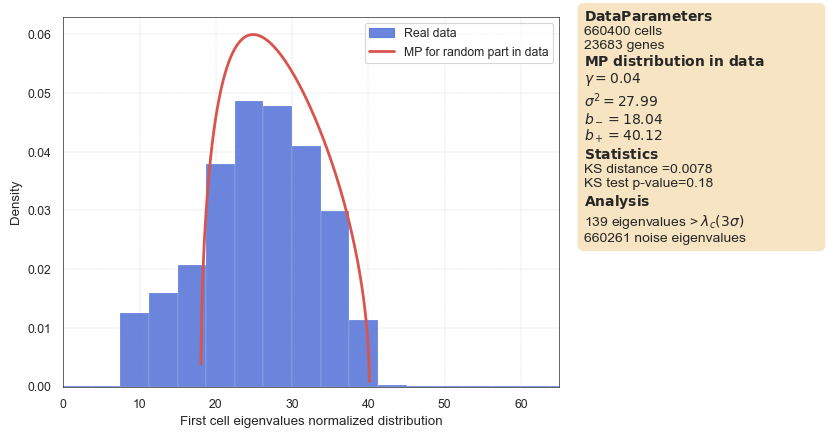

  0%|          | 0/20 [00:00<?, ?it/s]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
  5%|▌         | 1/20 [17:16<5:28:20, 1036.88s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 10%|█         | 2/20 [34:28<5:10:09, 1033.88s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
 15%|█▌        | 3/20 [51:44<4:53:13, 1034.93s/it]/home/l202255179/micromamba/envs/stLENS/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_val

number of filtered signals: 68


AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'stlens'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

In [ ]:
stlens_adata = stlens.find_optimal_pc(adata, plot_mp = True, device='gpu', tmp_directory='./output/stereoseq')
stlens_adata

In [ ]:
stlens_adata = stlens.pca(stlens_adata)
stlens_adata

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn', 'stlens'
    obsm: 'cell_border', 'spatial', 'X_pca_stlens'
    layers: 'counts'

In [ ]:
import scanpy as sc

sc.pp.neighbors(stlens_adata, use_rep='X_pca_stlens', metric='cosine')
sc.tl.umap(stlens_adata)

In [ ]:
sc.tl.leiden(stlens_adata)

/tmp/ipykernel_1298064/1054628897.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(stlens_adata)


/tmp/ipykernel_3437098/3686692821.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


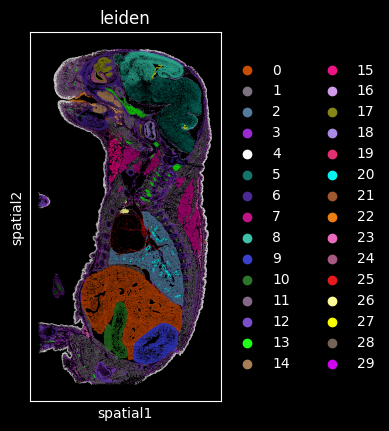

In [ ]:
fig = sc.pl.spatial(
    stlens_adata, color='leiden', spot_size=30,
    show=False, return_fig=True
)

fig.patch.set_facecolor('black')
for ax in fig.axes:
    ax.set_facecolor('black')
    ax.invert_yaxis()   
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    if ax.title: ax.title.set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

    
    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_color('white')
        if leg.get_title() is not None:
            leg.get_title().set_color('white')

    # 각 axes 위의 Text(‘on data’ 라벨 등)도 흰색
    for t in ax.texts:
        t.set_color('white')

fig.savefig(
    'path/spatial_stlens.pdf',
    format='pdf', bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)

### fixed-PC approach (50PC)

In [ ]:
scanpy_ref = sc.read_h5ad("./scanpy_out.h5ad")
scanpy_ref

AnnData object with n_obs × n_vars = 1191339 × 29221
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y'
    var: 'real_gene_name'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'

In [ ]:
import scanpy as sc

scanpy_ref.layers["counts"] = scanpy_ref.X.copy()
sc.pp.filter_cells(scanpy_ref, min_genes=200)
sc.pp.filter_genes(scanpy_ref, min_cells=15)
scanpy_ref

AnnData object with n_obs × n_vars = 660400 × 23683
    obs: 'dnbCount', 'area', 'id', 'orig.ident', 'x', 'y', 'n_genes'
    var: 'real_gene_name', 'n_cells'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'cell_border', 'spatial'
    layers: 'counts'

In [ ]:
sc.pp.normalize_total(scanpy_ref)
sc.pp.log1p(scanpy_ref)

sc.pp.pca(scanpy_ref)
sc.pp.neighbors(scanpy_ref, use_rep='X_pca')
sc.tl.umap(scanpy_ref)
sc.tl.leiden(scanpy_ref)

/tmp/ipykernel_3873316/4208730378.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(scanpy_ref)


/tmp/ipykernel_3437098/2791010961.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  fig = sc.pl.spatial(


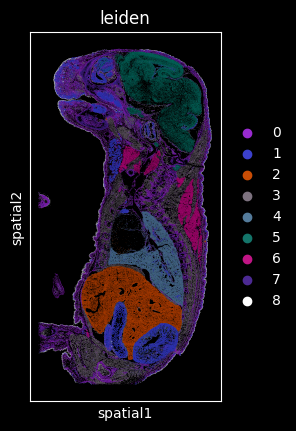

In [ ]:
fig = sc.pl.spatial(
    scanpy_ref, color='leiden', spot_size=30,
    show=False, return_fig=True
)

fig.patch.set_facecolor('black')
for ax in fig.axes:
    ax.set_facecolor('black')
    ax.invert_yaxis()   # 상하반전 (이미 뒤집혀 있다면 이 줄로 원상복귀)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    if ax.title: ax.title.set_color('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

    # legend 글자 흰색
    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_color('white')
        if leg.get_title() is not None:
            leg.get_title().set_color('white')

    # 각 axes 위의 Text(‘on data’ 라벨 등)도 흰색
    for t in ax.texts:
        t.set_color('white')

fig.savefig(
    'path/spatial_50pc_resol1.pdf',
    format='pdf', bbox_inches='tight',
    facecolor=fig.get_facecolor(),
)

## Comparison of clustering performance between stLENS and the fixed-PC approach (50PCs) under matched resolution and cluster number

### stLENS

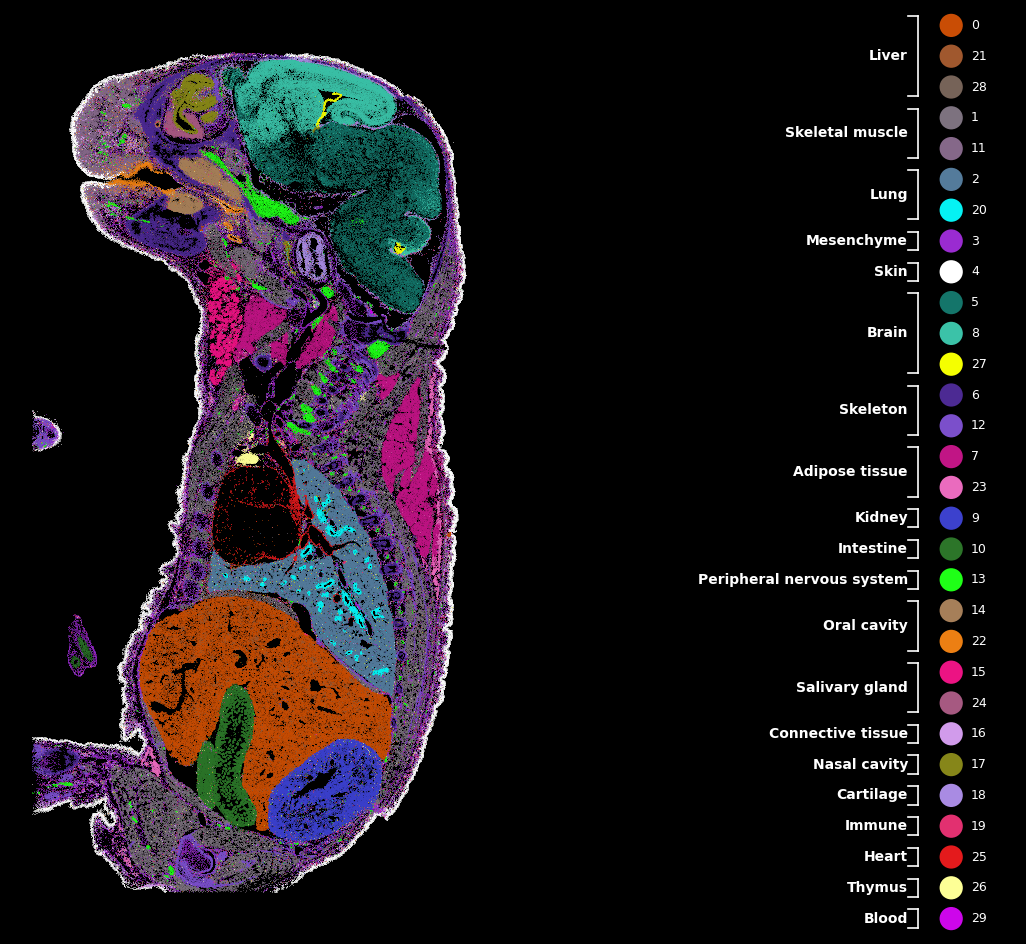

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# CSV 로드
df = pd.read_csv('path/organ_labeling_stlens.csv')
df['cluster'] = df['cluster'].astype(str)

cluster_color       = dict(zip(df['cluster'], df['color']))
cluster_organ_label = dict(zip(df['cluster'], df['organ_label']))
leiden_cats         = sorted(df['cluster'].unique(), key=int)

# 대분류 = organ_label 그대로
cluster_top = {c: cluster_organ_label[c] for c in leiden_cats}

# 순서: 각 top의 최소 cluster 번호 기준
top_min = {}
for c in leiden_cats:
    top_min.setdefault(cluster_top[c], []).append(int(c))
top_order = sorted(top_min, key=lambda t: min(top_min[t]))

# legend rows 배치
rows = []
for top in top_order:
    for c in sorted(top_min[top]):
        rows.append((str(c), top))

n_rows = len(rows)

# figure
coords     = stlens_adata.obsm['spatial']
leiden_arr = stlens_adata.obs['leiden'].astype(str).values

fig, (ax_sp, ax_lg) = plt.subplots(
    1, 2, figsize=(14, 12),
    gridspec_kw={'width_ratios': [3, 2], 'wspace': 0.05},
    facecolor='black'
)
for ax in (ax_sp, ax_lg):
    ax.set_facecolor('black')

# spatial
for cid in leiden_cats:
    mask = leiden_arr == cid
    ax_sp.scatter(coords[mask, 0], coords[mask, 1],
                  s=0.2, c=cluster_color[cid], linewidths=0)
ax_sp.set_aspect('equal')
ax_sp.axis('off')

# legend 좌표
top_text_x, bracket1_x = 1.20, 1.25
dot_x,      num_x      = 1.42, 1.52

# cluster dot + 번호
for idx, (cid, _) in enumerate(rows):
    y = n_rows - idx - 1
    ax_lg.scatter(dot_x, y, s=280, c=cluster_color[cid],
                  edgecolors='none', zorder=3)
    ax_lg.text(num_x, y, cid, va='center', ha='left',
               fontsize=9, color='white')

# outer bracket (대분류)
top_ys = {}
for idx, (_, top) in enumerate(rows):
    top_ys.setdefault(top, []).append(n_rows - idx - 1)

for top, ys in top_ys.items():
    y0, y1 = min(ys), max(ys); y_mid = (y0 + y1) / 2
    pad, cap = 0.30, 0.05
    ax_lg.plot([bracket1_x]*2, [y0 - pad, y1 + pad], '-', color='white', lw=1.2)
    ax_lg.plot([bracket1_x - cap, bracket1_x], [y0 - pad]*2, '-', color='white', lw=1.2)
    ax_lg.plot([bracket1_x - cap, bracket1_x], [y1 + pad]*2, '-', color='white', lw=1.2)
    ax_lg.text(top_text_x, y_mid, top, va='center', ha='right',
               fontsize=10, fontweight='bold', color='white')

ax_lg.set_xlim(-0.4, 1.75)
ax_lg.set_ylim(-0.5, n_rows - 0.5)
ax_lg.axis('off')

fig.savefig(
    'path/spatial_stlens_v2.pdf',
    format='pdf', bbox_inches='tight', facecolor='black'
)
plt.show()

### fixed-PC approach (50PCs)

In [ ]:
adata_50pc = scanpy_ref.copy()

In [ ]:
import rapids_singlecell as rsc

for i in range(10, 30, 1):
    res = i / 10
    rsc.tl.leiden(adata_50pc, resolution=res, key_added=f"leiden_{res:.1f}")
    print(f"Number of clusters for resolution {res:.1f}: {len(adata_50pc.obs[f'leiden_{res:.1f}'].unique())}")

Number of clusters for resolution 1.0: 10
Number of clusters for resolution 1.1: 10
Number of clusters for resolution 1.2: 10
Number of clusters for resolution 1.3: 10
Number of clusters for resolution 1.4: 10
Number of clusters for resolution 1.5: 12
Number of clusters for resolution 1.6: 15
Number of clusters for resolution 1.7: 18
Number of clusters for resolution 1.8: 18
Number of clusters for resolution 1.9: 17
Number of clusters for resolution 2.0: 36
Number of clusters for resolution 2.1: 24
Number of clusters for resolution 2.2: 23
Number of clusters for resolution 2.3: 26
Number of clusters for resolution 2.4: 30
Number of clusters for resolution 2.5: 91
Number of clusters for resolution 2.6: 124
Number of clusters for resolution 2.7: 115
Number of clusters for resolution 2.8: 128
Number of clusters for resolution 2.9: 140


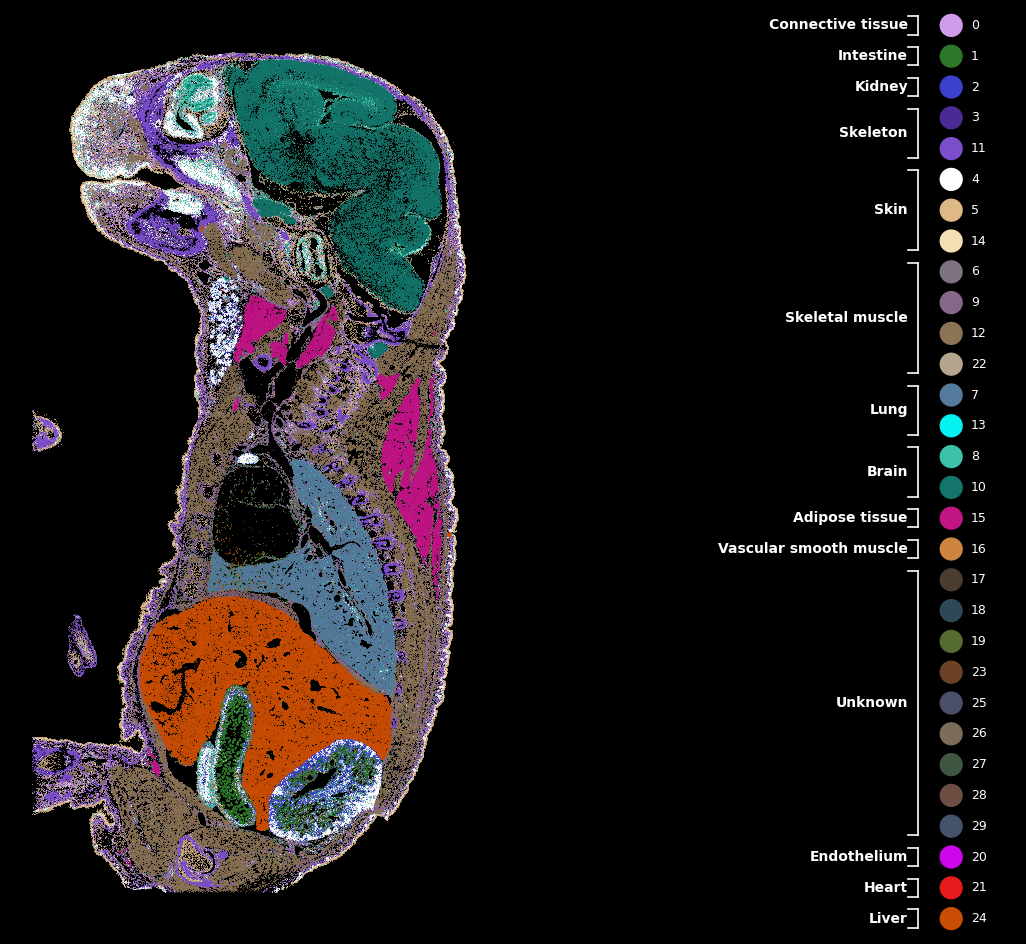

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# CSV 로드
df = pd.read_csv('path/organ_labeling_50pc_2.4.csv')
df['cluster'] = df['cluster'].astype(str)

cluster_color       = dict(zip(df['cluster'], df['color']))
cluster_organ_label = dict(zip(df['cluster'], df['organ_label']))
leiden_cats         = sorted(df['cluster'].unique(), key=int)

# 대분류 = organ_label 그대로
cluster_top = {c: cluster_organ_label[c] for c in leiden_cats}

# 순서: 각 top의 최소 cluster 번호 기준
top_min = {}
for c in leiden_cats:
    top_min.setdefault(cluster_top[c], []).append(int(c))
top_order = sorted(top_min, key=lambda t: min(top_min[t]))

# legend rows 배치
rows = []
for top in top_order:
    for c in sorted(top_min[top]):
        rows.append((str(c), top))

n_rows = len(rows)

# figure
coords     = adata_50pc.obsm['spatial']
leiden_arr = adata_50pc.obs['leiden_2.4'].astype(str).values

fig, (ax_sp, ax_lg) = plt.subplots(
    1, 2, figsize=(14, 12),
    gridspec_kw={'width_ratios': [3, 2], 'wspace': 0.05},
    facecolor='black'
)
for ax in (ax_sp, ax_lg):
    ax.set_facecolor('black')

# spatial
for cid in leiden_cats:
    mask = leiden_arr == cid
    ax_sp.scatter(coords[mask, 0], coords[mask, 1],
                  s=0.3, c=cluster_color[cid], linewidths=0)
ax_sp.set_aspect('equal')
ax_sp.axis('off')

# legend 좌표
top_text_x, bracket1_x = 1.20, 1.25
dot_x,      num_x      = 1.42, 1.52

# cluster dot + 번호
for idx, (cid, _) in enumerate(rows):
    y = n_rows - idx - 1
    ax_lg.scatter(dot_x, y, s=280, c=cluster_color[cid],
                  edgecolors='none', zorder=3)
    ax_lg.text(num_x, y, cid, va='center', ha='left',
               fontsize=9, color='white')

# outer bracket (대분류)
top_ys = {}
for idx, (_, top) in enumerate(rows):
    top_ys.setdefault(top, []).append(n_rows - idx - 1)

for top, ys in top_ys.items():
    y0, y1 = min(ys), max(ys); y_mid = (y0 + y1) / 2
    pad, cap = 0.30, 0.05
    ax_lg.plot([bracket1_x]*2, [y0 - pad, y1 + pad], '-', color='white', lw=1.2)
    ax_lg.plot([bracket1_x - cap, bracket1_x], [y0 - pad]*2, '-', color='white', lw=1.2)
    ax_lg.plot([bracket1_x - cap, bracket1_x], [y1 + pad]*2, '-', color='white', lw=1.2)
    ax_lg.text(top_text_x, y_mid, top, va='center', ha='right',
               fontsize=10, fontweight='bold', color='white')

ax_lg.set_xlim(-0.4, 1.75)
ax_lg.set_ylim(-0.5, n_rows - 0.5)
ax_lg.axis('off')

fig.savefig(
    'path/spatial_50pc_suppl.pdf',
    format='pdf', bbox_inches='tight', facecolor='black'
)
plt.show()
